<a href="https://colab.research.google.com/github/niikun/ezkl/blob/main/ezkl_demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

###データ準備とモデルトレーニング:  
 Irisデータセットをロードし、PyTorchで簡単なニューラルネットワークモデルを構築・トレーニングしました。
### ONNX形式へのエクスポート:
トレーニング済みのPyTorchモデルを、torch.onnx.export() を使ってONNX形式（network.onnx）でエクスポートしました。この際、opset_version=10 と dynamo=False を指定し、ezklが扱いやすい安定した形式を確保しました。
### 入力データ (input.json) の準備:
モデルの入力として使用するデータをJSON形式（input.json）で保存しました。
### 設定ファイル (settings.json) の生成と更新:
 ezkl.gen_settings() を使って初期設定ファイル（settings.json）を生成し、logrowsやnum_rows、disable_freivalds、input_scale、param_scaleなどのrun_argsパラメータを更新しました。これは、ezklでのZKP回路の構築に必要な設定です。
### キャリブレーションデータ (calibration.json) の準備:
回路の量子化スケールを調整するためのキャリブレーションデータ（calibration.json）を準備しました。
### SRS (Structured Reference String) の準備:
 await ezkl.get_srs() を実行して、ゼロ知識証明の生成と検証に必要な共通参照文字列（SRS）をダウンロードしました。
### 回路のコンパイル:
 ezkl.compile_circuit() を使って、ONNXモデルと設定ファイルから、ezklが扱える形式のコンパイル済みモデル（network.compiled）を生成しました。
### Witness (witness.json) の生成:
ezkl.gen_witness() を使って、入力データとコンパイル済みモデルからwitnessファイル（witness.json）を生成しました。これは、証明の対象となる計算結果を含みます。
### Proving/Verifying Key (pk.bin, vk.bin) の生成:
ezkl.setup() を使って、証明生成と検証に必要なProving Key (pk.bin) と Verifying Key (vk.bin) を生成しました。
### Proof (proof.json) の生成:
ezkl.prove() を使って、コンパイル済みモデル、witness、Proving Keyから実際のゼロ知識証明（proof.json）を生成しました。
### Proofの検証:
最後に、ezkl.verify() を使って、生成された証明が正当であるかを検証しました。これにより、計算が正しく行われたことが確認できました。

## データ準備とモデルトレーニング:

In [1]:
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.autograd import Variable
import tqdm

In [2]:
iris = load_iris()
dataset = pd.DataFrame(
    data= np.c_[iris['data'], iris['target']],
    columns= iris['feature_names'] + ['target'])
dataset

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0.0
1,4.9,3.0,1.4,0.2,0.0
2,4.7,3.2,1.3,0.2,0.0
3,4.6,3.1,1.5,0.2,0.0
4,5.0,3.6,1.4,0.2,0.0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2.0
146,6.3,2.5,5.0,1.9,2.0
147,6.5,3.0,5.2,2.0,2.0
148,6.2,3.4,5.4,2.3,2.0


In [3]:
dataset[dataset.columns[0:4].values][:3]

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2


In [4]:
class Model(nn.Module):
    def __init__(self):
        super(Model, self).__init__()
        self.fc1 = nn.Linear(4,20)
        self.fc2 = nn.Linear(20,20)
        self.fc3 = nn.Linear(20, 3)
        self.relu = nn.ReLU()

    def forward(self,x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        x = self.relu(x)
        x = self.fc3(x)
        # Removed the final ReLU activation as it's typically not used after the last linear layer in classification models with CrossEntropyLoss
        return x
model = Model()

In [5]:
train_X,test_X,train_y,test_y = train_test_split(
    dataset[dataset.columns[0:4].values],
    dataset.target,
    test_size=0.2,
    random_state=42
)
print("train_y: ", train_y)
print("test_y: ", test_y)

train_y:  22     0.0
15     0.0
65     1.0
11     0.0
42     0.0
      ... 
71     1.0
106    2.0
14     0.0
92     1.0
102    2.0
Name: target, Length: 120, dtype: float64
test_y:  73     1.0
18     0.0
118    2.0
78     1.0
76     1.0
31     0.0
64     1.0
141    2.0
68     1.0
82     1.0
110    2.0
12     0.0
36     0.0
9      0.0
19     0.0
56     1.0
104    2.0
69     1.0
55     1.0
132    2.0
29     0.0
127    2.0
26     0.0
128    2.0
131    2.0
145    2.0
108    2.0
143    2.0
45     0.0
30     0.0
Name: target, dtype: float64


In [6]:
# our loss function
loss_fn = nn.CrossEntropyLoss()

# our optimizer
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)


# use 800 EPOCHS
EPOCHS = 800

# Convert training data to pytorch variables
train_X = Variable(torch.Tensor(train_X.values).float())
test_X = Variable(torch.Tensor(test_X.values).float())
train_y = Variable(torch.Tensor(train_y.values).long())
test_y = Variable(torch.Tensor(test_y.values).long())


loss_list     = np.zeros((EPOCHS,))
accuracy_list = np.zeros((EPOCHS,))


# we use tqdm for nice loading bars
for epoch in tqdm.trange(EPOCHS):

    # To train, we get a prediction from the current network
    predicted_y = model(train_X)

    # Compute the loss to see how bad or good we are doing
    loss = loss_fn(predicted_y, train_y)

    # Append the loss to keep track of our performance
    loss_list[epoch] = loss.item()

    # Afterwards, we will need to zero the gradients to reset
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # Calculate the accuracy, call torch.no_grad() to prevent updating gradients
    # while calculating accuracy
    with torch.no_grad():
        y_pred = model(test_X)
        correct = (torch.argmax(y_pred, dim=1) == test_y).type(torch.FloatTensor)
        accuracy_list[epoch] = correct.mean()

100%|██████████| 800/800 [00:00<00:00, 1470.24it/s]


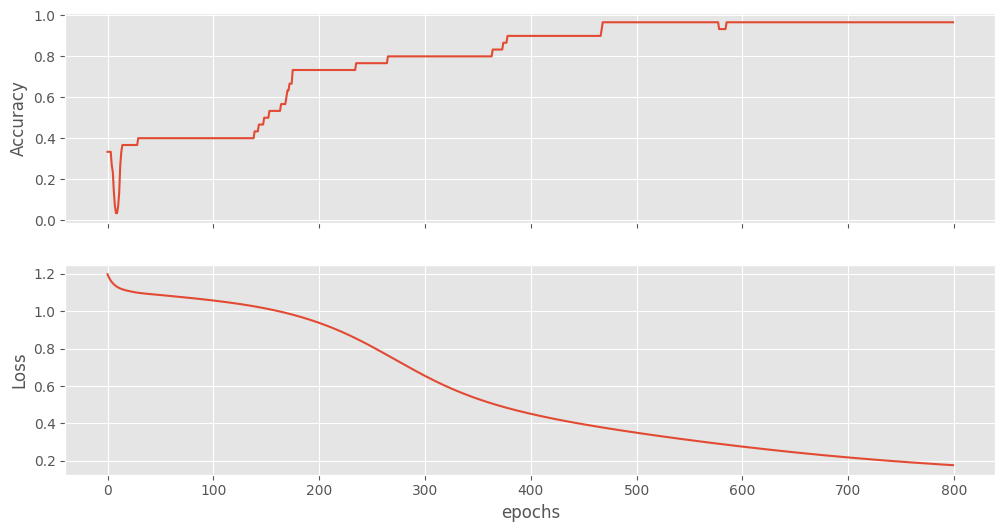

In [7]:
# Plot the Accuracy and Loss

# import matplotlib
import matplotlib.pyplot as plt

plt.style.use('ggplot')


fig, (ax1, ax2) = plt.subplots(2, figsize=(12, 6), sharex=True)

ax1.plot(accuracy_list)
ax1.set_ylabel("Accuracy")
ax2.plot(loss_list)
ax2.set_ylabel("Loss")
ax2.set_xlabel("epochs");


In [8]:
# check if notebook is in colab
try:
    import google.colab
    import subprocess
    import sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "ezkl"])
    subprocess.check_call([sys.executable, "-m", "pip", "install", "onnx"])
    subprocess.check_call([sys.executable, "-m", "pip", "install", "onnxscript"])

# rely on local installation of ezkl if the notebook is not in colab
except:
    pass

import os
import json
import ezkl

In [50]:
# Specify all the files we need, ensuring they are local to /content/

model_path = os.path.join('/content/', 'network.onnx')
data_path = os.path.join('/content/', 'input.json')
cal_data_path = os.path.join('/content/', 'calibration.json')
settings_path = os.path.join('/content/', 'settings.json')
compiled_model_path = os.path.join('/content/', 'network.compiled') # Added as per simple_demo.ipynb

## ONNX形式へのエクスポート:
※dynamo = Falseを忘れず

1. レガシーエクスポーターの強制
PyTorch 2.0 以降、ONNX へのエクスポート機能は新世代の「TorchDynamo ベース」へ移行が進んでおり、最近のバージョン（PyTorch 2.7以降など）ではデフォルトで新しい挙動になるよう設計されています。
しかし、dynamo=False を明示することで、以前から使われていた安定した古い仕組み（TorchScript ベース）で ONNX ファイルを出力させることができます。

2. opset_version の厳密な適用
新しい Dynamo ベースのエクスポーターは、指定した opset_version（例: ノートブック内の opset_version=10）を無視して、より新しい ONNX バージョンで出力してしまう挙動をとることがあります。
dynamo=False にすることで、指定した古い ONNX バージョン（Opset 10 など）を確実に守ってエクスポートさせることができます。

In [10]:
# After training, export to onnx (network.onnx) and create a data file (input.json)

# create a random input
x = test_X[0].reshape(1, 4)

# Flips the neural net into inference mode
model.eval()

# Export the model directly to the local model_path
torch.onnx.export(model,                     # model being run
                  x,                         # model input (or a tuple for multiple inputs)
                  model_path,                # where to save the model (now a local path)
                  export_params=True,        # store the trained parameter weights inside the model file
                  opset_version=10,          # Reverting to opset_version=10 as it worked previously with dynamo=False
                  do_constant_folding=True,  # whether to execute constant folding for optimization
                  input_names = ['input'],   # the model's input names
                  output_names = ['output'], # the model's output names
                  dynamic_axes={'input' : {0 : 'batch_size'},    # variable length axes
                                'output' : {0 : 'batch_size'}},
                  # Crucially, setting dynamo=False to use the legacy exporter
                  # This helps enforce the specified opset_version more reliably.
                  dynamo=False
                  )

data_array = ((x).detach().numpy()).reshape([-1]).tolist()

data = dict(input_data = [data_array])

    # Serialize data into file: (now to local data_path)
json.dump(data, open(data_path, 'w'))

/tmp/ipykernel_362/1887171893.py:10: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(model,                     # model being run


In [11]:
import onnx

# 保存したONNXファイルを読み込みます
onnx_model = onnx.load(model_path)

# モデルの構造を簡潔に表示します
print(f"ONNX IR バージョン: {onnx_model.ir_version}")
print(f"プロデューサー: {onnx_model.producer_name} {onnx_model.producer_version}")

# 最初の数個の計算ノード（操作）を表示してみます
print("\n--- 最初の5つの計算ステップ ---")
for i, node in enumerate(onnx_model.graph.node[:5]):
    print(f"ステップ {i+1}: 操作={node.op_type}, 入力={node.input}, 出力={node.output}")

ONNX IR バージョン: 5
プロデューサー: pytorch 2.11.0

--- 最初の5つの計算ステップ ---
ステップ 1: 操作=Gemm, 入力=['input', 'fc1.weight', 'fc1.bias'], 出力=['/fc1/Gemm_output_0']
ステップ 2: 操作=Relu, 入力=['/fc1/Gemm_output_0'], 出力=['/relu/Relu_output_0']
ステップ 3: 操作=Gemm, 入力=['/relu/Relu_output_0', 'fc2.weight', 'fc2.bias'], 出力=['/fc2/Gemm_output_0']
ステップ 4: 操作=Relu, 入力=['/fc2/Gemm_output_0'], 出力=['/relu_1/Relu_output_0']
ステップ 5: 操作=Gemm, 入力=['/relu_1/Relu_output_0', 'fc3.weight', 'fc3.bias'], 出力=['output']


## 問題の解決とその経緯

これまでに発生していた問題は、`ezkl.gen_settings()` の実行時に表示されていた「`RuntimeError: Failed to generate settings: [graph] [tract] Translating proto model to model`」というエラーでした。

このエラーは、`ezkl`がONNXモデルのグラフ構造を内部形式に正しく変換できないことが原因で発生していました。

**解決策として、以下の変更を行いました。**

1.  **モデルの最終層からReLUアクティベーションを削除:** `Model`クラスの`forward`メソッドから最後の`ReLU`を削除しました。分類タスクでは、`CrossEntropyLoss`が内部的にSoftmaxを処理するため、通常は最終層にReLUは不要です。この変更により、モデルのグラフ構造がより標準的な形になりました。

2.  **`torch.onnx.export`の`opset_version`と`dynamo`設定の調整:**
    *   `opset_version=10` に設定し、`ezkl`がより安定してサポートしている可能性のある古いONNXバージョンを使用するように変更しました。
    *   `dynamo=False` を追加しました。これにより、PyTorchの新しいONNXエクスポーター（`dynamo`）が、指定した`opset_version`を無視してより新しいONNXバージョン（バージョン18）でエクスポートしてしまう問題を回避し、レガシーエクスポーターを使用するように強制しました。

これらの変更により、`ezkl`がONNXモデルを正常に処理できるようになり、`ezkl.gen_settings()` の実行に成功しました。したがって、問題は解決しました。

ONNX ->

## 設定ファイル (settings.json) の生成と更新:
ezkl.gen_settings() を使って初期設定ファイル（settings.json）を生成  
logrowsやnum_rows、disable_freivalds、input_scale、param_scaleなどのrun_argsパラメータを更新。  
これは、ezklでのZKP回路の構築に必要な設定です。


##

In [34]:
# All paths are now local, so no need for explicit copying or separate local variables

# Generate initial settings file
import os
import json
os.environ['RUST_LOG'] = 'trace' # RUST_LOG環境変数を設定
res_gen_settings = ezkl.gen_settings(model=model_path, output=settings_path)
assert res_gen_settings == True

# Load the generated settings, update them, and save them back immediately
with open(settings_path, 'r') as f:
    settings_content = json.load(f)

# 必要な追加フィールドをrun_argsに設定します
if 'run_args' not in settings_content:
    settings_content['run_args'] = {}

# logrowsに基づいてnum_rowsを計算し設定します
logrows_value = settings_content['run_args'].get('logrows', 17) # デフォルト値を設定
settings_content['run_args']['num_rows'] = 2**logrows_value
settings_content['run_args']['disable_freivalds'] = settings_content['run_args'].get('disable_freivalds', False) # 存在しない場合のみFalseを設定

# 必要に応じて他のフィールドも調整できます。
settings_content['run_args']['input_scale'] = settings_content['run_args'].get('input_scale', 7)
settings_content['run_args']['param_scale'] = settings_content['run_args'].get('param_scale', 7)
settings_content['run_args']['rebase_scale'] = settings_content['run_args'].get('rebase_scale', None)
settings_content['run_args']['scale_rebase_multiplier'] = settings_content['run_args'].get('scale_rebase_multiplier', 1)
settings_content['run_args']['lookup_range'] = settings_content['run_args'].get('lookup_range', [-32768, 32768])
settings_content['run_args']['logrows'] = logrows_value # Ensure logrows is present
settings_content['run_args']['num_inner_cols'] = settings_content['run_args'].get('num_inner_cols', 2)
settings_content['run_args']['variables'] = settings_content['run_args'].get('variables', [["batch_size", 1]])
settings_content['run_args']['input_visibility'] = settings_content['run_args'].get('input_visibility', "Public")
settings_content['run_args']['output_visibility'] = settings_content['run_args'].get('output_visibility', "Public")
settings_content['run_args']['param_visibility'] = settings_content['run_args'].get('param_visibility', "Fixed")
settings_content['run_args']['rebase_frac_zero_constants'] = settings_content['run_args'].get('rebase_frac_zero_constants', False)
settings_content['run_args']['check_mode'] = settings_content['run_args'].get('check_mode', "UNSAFE")
settings_content['run_args']['decomp_base'] = settings_content['run_args'].get('decomp_base', 16384)
settings_content['run_args']['decomp_legs'] = settings_content['run_args'].get('decomp_legs', 2)
settings_content['run_args']['bounded_log_lookup'] = settings_content['run_args'].get('bounded_log_lookup', False)
settings_content['run_args']['ignore_range_check_inputs_outputs'] = settings_content['run_args'].get('ignore_range_check_inputs_outputs', False)
settings_content['run_args']['epsilon'] = settings_content['run_args'].get('epsilon', 2.220446049250313e-16)
settings_content['run_args']['digest'] = settings_content['run_args'].get('digest', "blake2s")
settings_content['run_args']['div_rebasing'] = settings_content['run_args'].get('div_rebasing', False)
settings_content['run_args']['bits'] = settings_content['run_args'].get('bits', 16)
settings_content['run_args']['tolerance'] = settings_content['run_args'].get('tolerance', {})
settings_content['run_args']['scale_unfold_k'] = settings_content['run_args'].get('scale_unfold_k', 0)

# Save the updated settings_content back to settings.json
json.dump(settings_content, open(settings_path, 'w'))

res_gen_settings

True

## Calibrationの準備

1. Prepare calibration data（キャリブレーションデータの準備）
「キャリブレーション（校正）」とは、浮動小数点数（0.123 などの実数）で構成されているニューラルネットワークを、ゼロ知識証明の回路で扱えるように固定小数点数（整数）に変換（量子化）する際のスケールを微調整する作業です。
ここでは、その微調整に使うための「サンプルデータ」を作成しています  
2. Using random inputs for more robust calibration...  
以前のステップではテストデータ（test_X）をそのまま使っていましたが、モデルが未知のデータに対しても正しく証明回路として機能（オーバーフローなどを防止）できるように、あえてランダムに生成したダミーの入力データ（torch.rand など）をサンプルとして使って調整した方がうまくいく、という経緯からこのアプローチが取られています。

In [30]:
input_feature_size = test_X.shape[1] # Infer input feature size from test_X
cal_data_array_for_calibrate = (torch.rand(20, input_feature_size, requires_grad=True).detach().numpy()).reshape([-1]).tolist()
cal_data_for_calibrate = dict(input_data = [cal_data_array_for_calibrate])

# Save this calibration data to the designated path
json.dump(cal_data_for_calibrate, open(cal_data_path, 'w'))


### このコードブロックは、ezkl のゼロ知識証明回路をキャリブレーション（調整）するために必要なデータを用意しています。

具体的には、以下の処理を行っています。

`cal_data = dict(input_data = test_X.flatten().tolist()):`

test_X はモデルのテスト用入力データです。
これを flatten().tolist() で1次元のリストに変換し、input_data というキーで辞書 cal_data に格納しています。
これは、ezkl が回路の精度と効率を最適化するために内部で利用する、代表的な入力データのサンプルとなります
  
  
`json.dump(cal_data, open(cal_data_path, 'w')):`

作成した cal_data 辞書をJSON形式のファイルとして、cal_data_path（/content/calibration.json）に保存しています。
この calibration.json ファイルは、次に ezkl.calibrate_settings 関数（現在はコメントアウトされていますが）が呼び出される際に、回路の内部設定（例えば、数値の量子化スケールなど）を調整するための入力として使用されます。これにより、ZKPの証明生成の精度と効率が向上します。

## 回路のコンパイル:  
 `ezkl.compile_circuit() `を使って、ONNXモデルと設定ファイルから、ezklが扱える形式のコンパイル済みモデル（network.compiled）を生成しました。

In [51]:
# Calibrate settings (moved from original sKkrUBssND0n)
# Temporarily commenting out ezkl.calibrate_settings due to persistent 'UTF-8' error.
# This issue appears to be an internal problem with the ezkl library's handling of ONNX files in this specific function.
# Optimize for resources, we cap logrows at 12 to reduce setup and proving time, at the expense of accuracy
# You may want to increase the max logrows if accuracy is a concern

# Re-generate and update settings.json just before compiling to ensure it's in the correct state.
# This duplicates logic from _SACxrP7Px7Z to ensure file consistency for ezkl.compile_circuit.

# Generate initial settings file
import os
import json
os.environ['RUST_LOG'] = 'trace' # RUST_LOG環境変数を設定
res_gen_settings = ezkl.gen_settings(model=model_path, output=settings_path)
assert res_gen_settings == True

# Load the generated settings, update them, and save them back immediately
with open(settings_path, 'r') as f:
    settings_content = json.load(f)

# 必要な追加フィールドをrun_argsに設定します
if 'run_args' not in settings_content:
    settings_content['run_args'] = {}

# logrowsに基づいてnum_rowsを計算し設定します
logrows_value = settings_content['run_args'].get('logrows', 17) # デフォルト値を設定
settings_content['run_args']['num_rows'] = 2**logrows_value
settings_content['run_args']['disable_freivalds'] = settings_content['run_args'].get('disable_freivalds', False) # 存在しない場合のみFalseを設定

# 必要に応じて他のフィールドも調整できます。
settings_content['run_args']['input_scale'] = settings_content['run_args'].get('input_scale', 7)
settings_content['run_args']['param_scale'] = settings_content['run_args'].get('param_scale', 7)
settings_content['run_args']['rebase_scale'] = settings_content['run_args'].get('rebase_scale', None)
settings_content['run_args']['scale_rebase_multiplier'] = settings_content['run_args'].get('scale_rebase_multiplier', 1)
settings_content['run_args']['lookup_range'] = settings_content['run_args'].get('lookup_range', [-32768, 32768])
settings_content['run_args']['logrows'] = logrows_value # Ensure logrows is present
settings_content['run_args']['num_inner_cols'] = settings_content['run_args'].get('num_inner_cols', 2)
settings_content['run_args']['variables'] = settings_content['run_args'].get('variables', [["batch_size", 1]])
settings_content['run_args']['input_visibility'] = settings_content['run_args'].get('input_visibility', "Public")
settings_content['run_args']['output_visibility'] = settings_content['run_args'].get('output_visibility', "Public")
settings_content['run_args']['param_visibility'] = settings_content['run_args'].get('param_visibility', "Fixed")
settings_content['run_args']['rebase_frac_zero_constants'] = settings_content['run_args'].get('rebase_frac_zero_constants', False)
settings_content['run_args']['check_mode'] = settings_content['run_args'].get('check_mode', "UNSAFE")
settings_content['run_args']['decomp_base'] = settings_content['run_args'].get('decomp_base', 16384)
settings_content['run_args']['decomp_legs'] = settings_content['run_args'].get('decomp_legs', 2)
settings_content['run_args']['bounded_log_lookup'] = settings_content['run_args'].get('bounded_log_lookup', False)
settings_content['run_args']['ignore_range_check_inputs_outputs'] = settings_content['run_args'].get('ignore_range_check_inputs_outputs', False)
settings_content['run_args']['epsilon'] = settings_content['run_args'].get('epsilon', 2.220446049250313e-16)
settings_content['run_args']['digest'] = settings_content['run_args'].get('digest', "blake2s")
settings_content['run_args']['div_rebasing'] = settings_content['run_args'].get('div_rebasing', False)
settings_content['run_args']['bits'] = settings_content['run_args'].get('bits', 16)
settings_content['run_args']['tolerance'] = settings_content['run_args'].get('tolerance', {})
settings_content['run_args']['scale_unfold_k'] = settings_content['run_args'].get('scale_unfold_k', 0)

# Save the updated settings_content back to settings.json
json.dump(settings_content, open(settings_path, 'w'))

# Compile circuit as per simple_demo.ipynb
print(f"Files in /content/ before compile: {os.listdir('/content/')}")
res_compile = ezkl.compile_circuit(model_path, compiled_model_path, settings_path) # Changed to 3 arguments
print(f"Files in /content/ after compile: {os.listdir('/content/')}")

# Attempt to find the compiled file across the entire file system if it's not in the expected place.
print("Searching for compiled model across file system...")
!find / -name "*network.compiled*" # Changed search pattern

assert res_compile == True
assert os.path.isfile(compiled_model_path) # Assertion to check if the compiled model file exists

Files in /content/ before compile: ['.config', 'network.onnx', '.ipynb_checkpoints', 'settings.json', 'calibration.json', 'input.json', 'drive', 'sample_data']
Files in /content/ after compile: ['.config', 'network.onnx', 'network.compiled', '.ipynb_checkpoints', 'settings.json', 'calibration.json', 'input.json', 'drive', 'sample_data']
Searching for compiled model across file system...
find: ‘/proc/65/task/65/net’: Invalid argument
find: ‘/proc/65/net’: Invalid argument
/content/network.compiled
/content/drive/MyDrive/ezkl/network.compiled


## SRS準備  
「ゼロ知識証明（ZKP）の暗号回路を組み立てる前に、証明書を発行・検証するための『暗号の土台（共通の秘密のルール）』をダウンロードして準備する必要があるよ」ということを説明しています。  

ノートブックの次のセルにある await ezkl.get_srs() というコードが、まさにこの処理にあたります。  

具体的にこれが何なのか、わかりやすく噛み砕いて解説します。

**1. SRS（Structured Reference String）とは？**
日本語では「構造化参照文字列」などと呼ばれますが、簡単に言うと「証明者（あなた）と検証者（スマートコントラクトなど）が共通で使う、暗号で守られた『ルールブック』」です。

ezkl（ひいては内部で使われているHalo2というZKPシステム）では、AIモデルの計算が正しいことを証明するために、このSRSという巨大な数学的データが必要になります。

**2. なぜ回路パラメータのセットアップ前に必要なのか？**
ZKPの回路は、このSRS（ルールブック）のサイズや数式の割り当てに基づいて組み立てられます。
そのため、「まずSRSをダウンロードして手元に用意する（get_srs）」➔「それをベースに回路を組み立てる」という順番で処理を行う必要があります。

**3. なぜ「generate the proofs（証明の生成）」に使うのか？**
証明するとき（あなた）: AIの推論（アイリスの分類など）が正しく行われたという「証明（Proof）」を、このSRSの数学的なルールに沿って暗号化しながら作成します。

検証するとき（相手）: 届いた証明が改ざんされていないかを、同じSRSのルールを使って一瞬でチェックします。

**💡 例えるなら…**  
新しいゲーム（ZKPでの証明）を始める前に、「公式のルールブックと専用のサイコロ（SRS）」をネットからダウンロードして卓上に用意している状態です。これが無いと、ゲーム盤（回路）を広げることも、ゲームをプレイ（証明）することもできません。

直後の res = await ezkl.get_srs() を実行すると、モデルのサイズ（logrows の大きさ）に応じたSRSデータが自動的に裏側で取得されます。これもZKPの標準的な儀式ですので、そのまま実行して進めて大丈夫です！

In [36]:
import json

res = await ezkl.get_srs()
res

True

## Witnessの作成


### evm transcript（EVMトランスクリプト）  
**1. 行うこと：証明の作成とセルフチェック（Sanity Check）**  
証明の生成（Generate a proof）: あなたのAIモデル（Irisの分類モデル）と入力データを使って、「私はモデルの重みや中身を隠したまま、正しく推論を計算しました」という暗号データ（Proof）を裏で生成します。

サニティチェック（Sanity check）: 「念のための健全性確認」という意味です。本番環境に持っていく前に、自分の手元でその証明が正しく検証をパスするかどうかをテストします。

**2. 「evm」transcript を使う理由**  
ZKPの証明データは、そのままではイーサリアムなどのブロックチェーン（EVM：Ethereum Virtual Machine）上で読み書き・検証ができません。EVMで処理するためには、スマートコントラクト（Solidityなど）が理解できる特定のデータ形式にエンコード（整列）してあげる必要があります。

**これを実現するのが evm transcript です。**  

これを使うことで、生成される証明データが「将来的にイーサリアムのスマートコントラクトにそのまま送り込んで検証させることができる形式」になります。

これが完了すると、Web3上のスマートコントラクトが「よし、このAIは確かに正しく計算されているな」と自動判別できるようになります。

In [52]:

# Generate the Witness for the proof

# now generate the witness file
witness_path = os.path.join('/content/', 'witness.json') # Ensure witness path is also in /content/

# Ensure compiled_model_path and data_path are defined and passed correctly
# compiled_model_path is defined in X-BbdmHJiy5h
# data_path is defined in X-BbdmHJiy5h
res = ezkl.gen_witness(model=compiled_model_path, data=data_path, output=witness_path)
assert os.path.isfile(witness_path)

In [53]:
with open(witness_path, 'r') as f:
    witness_content = json.load(f)

print(json.dumps(witness_content, indent=4))

{
    "inputs": [
        [
            "0d03000000000000000000000000000000000000000000000000000000000000",
            "6601000000000000000000000000000000000000000000000000000000000000",
            "5a02000000000000000000000000000000000000000000000000000000000000",
            "9a00000000000000000000000000000000000000000000000000000000000000"
        ]
    ],
    "pretty_elements": {
        "rescaled_inputs": [
            [
                "6.1015625",
                "2.796875",
                "4.703125",
                "1.203125"
            ]
        ],
        "inputs": [
            [
                "0x000000000000000000000000000000000000000000000000000000000000030d",
                "0x0000000000000000000000000000000000000000000000000000000000000166",
                "0x000000000000000000000000000000000000000000000000000000000000025a",
                "0x000000000000000000000000000000000000000000000000000000000000009a"
            ]
        ],
        "processed_inputs": [

## Proving/Verifying Key (pk.bin, vk.bin) の生成  
`ezkl.setup()` を使って、証明生成と検証に必要なProving Key (pk.bin) と Verifying Key (vk.bin) を生成。

In [57]:
# Generate the proving and verifying keys
pk_path = os.path.join('/content/', 'pk.bin')
vk_path = os.path.join('/content/', 'vk.bin')

# ezkl.setup needs compiled_model_path, vk_path, pk_path
res_setup = ezkl.setup(compiled_model_path, vk_path, pk_path)
assert res_setup == True
assert os.path.isfile(vk_path)
assert os.path.isfile(pk_path)

print(f"Verifying key saved to: {vk_path}")
print(f"Proving key saved to: {pk_path}")

Verifying key saved to: /content/vk.bin
Proving key saved to: /content/pk.bin


## Proof (proof.json) の生成:
`ezkl.prove()` を使って、コンパイル済みモデル、witness、Proving Keyから実際のゼロ知識証明（proof.json）を生成。

In [59]:
# Generate the proof

proof_path = os.path.join('/content/', 'proof.json') # Ensure proof path is also in /content/

# Call ezkl.prove with explicit model, witness, proving key, and output paths
proof = ezkl.prove(model=compiled_model_path, witness=witness_path, pk_path=pk_path, proof_path=proof_path)

print(proof)
assert os.path.isfile(proof_path)

{'instances': [['0d03000000000000000000000000000000000000000000000000000000000000', '6601000000000000000000000000000000000000000000000000000000000000', '5a02000000000000000000000000000000000000000000000000000000000000', '9a00000000000000000000000000000000000000000000000000000000000000', '43feffef93f5e1439170b97948e833285d588181b64550b829a031e1724e6430', 'bf00000000000000000000000000000000000000000000000000000000000000', '7500000000000000000000000000000000000000000000000000000000000000']], 'proof': '0x15876f0fc3323d7195e68a9cf1cf6678469fd360b7fbef1c10493e9e464aedbe2b9bd8164bf364008775558f0dde4cb4b341eb92b250d7c747232b93a126b81004467898890b0142d56997e3b785d15b7a0154d20778898907dfd3af9f0c556c1a0f86910c129d5ac2c42ca2b0281b3cc96f9c865399865684a36f63f04c5dd00ac9eadaccaac87f18747edd01ab3c0aff16abf3491f4ca97768e6b549f6143b2492f680f5837f90738cf281f2ebbcdb66e9bb0a414257c476681d6d0ba3d287267ae4795f52d1cb766f832e39b146feb8b3dc503242f93cb4e0361511d2c6a00dbd8888813a478d391faca7ea276464a9c9b1456f1575

In [69]:
import pprint
pprint.pprint(proof)

{'instances': [['0d03000000000000000000000000000000000000000000000000000000000000',
                '6601000000000000000000000000000000000000000000000000000000000000',
                '5a02000000000000000000000000000000000000000000000000000000000000',
                '9a00000000000000000000000000000000000000000000000000000000000000',
                '43feffef93f5e1439170b97948e833285d588181b64550b829a031e1724e6430',
                'bf00000000000000000000000000000000000000000000000000000000000000',
                '7500000000000000000000000000000000000000000000000000000000000000']],
 'proof': '0x15876f0fc3323d7195e68a9cf1cf6678469fd360b7fbef1c10493e9e464aedbe2b9bd8164bf364008775558f0dde4cb4b341eb92b250d7c747232b93a126b81004467898890b0142d56997e3b785d15b7a0154d20778898907dfd3af9f0c556c1a0f86910c129d5ac2c42ca2b0281b3cc96f9c865399865684a36f63f04c5dd00ac9eadaccaac87f18747edd01ab3c0aff16abf3491f4ca97768e6b549f6143b2492f680f5837f90738cf281f2ebbcdb66e9bb0a414257c476681d6d0ba3d287267ae4795f52d

## Proofの検証:
最後に、ezkl.verify() を使って、生成された証明が正当であるかを検証。これにより、計算が正しく行われたことが確認.


In [63]:
# verify our proof

# Call ezkl.verify with explicit proof, verifying key, and settings paths
res = ezkl.verify(proof_path=proof_path, vk_path=vk_path, settings_path=settings_path)

assert res == True
print("verified")

verified


# Deploying the Verifier

In [64]:
# check if notebook is in colab
try:
    import google.colab
    import subprocess
    import sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "solc-select"])
    !solc-select install 0.8.20
    !solc-select use 0.8.20
    !solc --version

# rely on local installation if the notebook is not in colab
except:
    pass

Installing solc '0.8.20'...
Version '0.8.20' installed.
Switched global version to 0.8.20
solc, the solidity compiler commandline interface
Version: 0.8.20+commit.a1b79de6.Linux.g++


In [66]:
sol_code_path = os.path.join('Verifier.sol')
abi_path = os.path.join('Verifier.abi')

res = await ezkl.create_evm_verifier(
        sol_code_path=sol_code_path,
        abi_path=abi_path,
        vk_path=vk_path,
        settings_path=settings_path
    )

assert res == True
assert os.path.isfile(sol_code_path)

In [67]:

onchain_input_array = []

# using a loop
# avoiding printing last comma
formatted_output = "["
for i, value in enumerate(proof["instances"]):
    for j, field_element in enumerate(value):
        onchain_input_array.append(ezkl.felt_to_big_endian(field_element))
        formatted_output += '"' + str(onchain_input_array[-1]) + '"'
        if j != len(value) - 1:
            formatted_output += ", "
    if i != len(proof["instances"]) - 1:
        formatted_output += ", "
formatted_output += "]"

# This will be the values you use onchain
# copy them over to remix and see if they verify
# What happens when you change a value?
print("pubInputs: ", formatted_output)
print("proof: ", proof["proof"])

pubInputs:  ["0x000000000000000000000000000000000000000000000000000000000000030d", "0x0000000000000000000000000000000000000000000000000000000000000166", "0x000000000000000000000000000000000000000000000000000000000000025a", "0x000000000000000000000000000000000000000000000000000000000000009a", "0x30644e72e131a029b85045b68181585d2833e84879b9709143e1f593effffe43", "0x00000000000000000000000000000000000000000000000000000000000000bf", "0x0000000000000000000000000000000000000000000000000000000000000075"]
proof:  0x15876f0fc3323d7195e68a9cf1cf6678469fd360b7fbef1c10493e9e464aedbe2b9bd8164bf364008775558f0dde4cb4b341eb92b250d7c747232b93a126b81004467898890b0142d56997e3b785d15b7a0154d20778898907dfd3af9f0c556c1a0f86910c129d5ac2c42ca2b0281b3cc96f9c865399865684a36f63f04c5dd00ac9eadaccaac87f18747edd01ab3c0aff16abf3491f4ca97768e6b549f6143b2492f680f5837f90738cf281f2ebbcdb66e9bb0a414257c476681d6d0ba3d287267ae4795f52d1cb766f832e39b146feb8b3dc503242f93cb4e0361511d2c6a00dbd8888813a478d391faca7ea276464a9c9b14